In [1]:
import time

### Pandas

Tempo médio: 

In [2]:
import pandas as pd

tempos_pandas = []

for _ in range(10):
    start = time.perf_counter()

    rating_pandas = pd.read_csv(r'anime_data/rating_complete.csv')

    media_por_usuario = (rating_pandas[['user_id','anime_id', 'rating']]
            .rename(columns={
                'user_id' : 'id_usuario',
                'anime_id': 'id_anime',
                'rating'  : 'avaliacao'
            })
            .groupby(['id_usuario'])
            .agg({'id_anime': 'count', 'avaliacao': 'mean'})
            .rename(columns={
                'id_anime': 'qtd_animes', 
                'avaliacao': 'media_avaliacao'
                })
            .reset_index()
            .sort_values(by='id_usuario')
            .set_index('id_usuario')
            )
    end = time.perf_counter()
    tempos_pandas.append(end - start)
print(f'Tempo medio de execucao com Pandas: {sum(tempos_pandas)/len(tempos_pandas)} segundos')

Tempo medio de execucao com Pandas: 11.12939176999862 segundos


### Polars

Tempo médio: 

In [6]:
import polars as pl

tempos_polars = []

for _ in range(10):
    start = time.perf_counter()


    rating_polars = pl.scan_csv("anime_data/rating_complete.csv")

    media_por_usuario = (
        rating_polars
        .select(["user_id", "anime_id", "rating"])
        .rename({
            "user_id": "id_usuario",
            "anime_id": "id_anime",
            "rating": "avaliacao",
        })
        .group_by(["id_usuario"])
        .agg(
            pl.col("id_anime").count().alias("qtd_animes"),
            pl.col("avaliacao").mean().alias("media_avaliacao"),
        )
        .sort("id_usuario")
        .collect()
    )
    end = time.perf_counter()
    tempos_polars.append(end - start)
print(f'Tempo medio de execucao com Polars: {sum(tempos_polars)/len(tempos_polars)} segundos')

Tempo medio de execucao com Polars: 1.4377617600010126 segundos


In [7]:
media_por_usuario.head()

id_usuario,qtd_animes,media_avaliacao
i64,u32,f64
0,35,7.4
1,103,8.058252
2,51,8.333333
3,315,7.603175
4,118,7.652542


In [8]:
print(tempos_pandas)
print(tempos_polars)

[11.795709999998508, 10.33688329999859, 11.790648599999258, 12.2667794999943, 12.927232399997592, 11.625251800003753, 12.556615300003614, 10.021531399994274, 9.77129910000076, 8.201966299995547]
[1.407104599995364, 1.4274277000004076, 1.3518353999970714, 1.3447458000009647, 1.3811917999992147, 1.410803400001896, 1.4247455000004265, 1.4096866000036243, 1.4371922000063933, 1.7828846000047633]


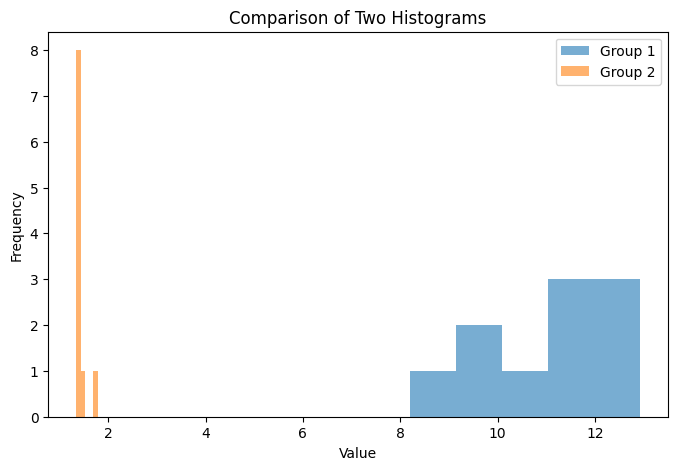

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
group1 = np.random.normal(0, 1, 1000)
group2 = np.random.normal(1, 1, 1000)

plt.figure(figsize=(8, 5))

plt.hist(tempos_pandas, bins=5, alpha=0.6, label='Group 1')
plt.hist(tempos_polars, bins=5, alpha=0.6, label='Group 2')

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Comparison of Two Histograms")
plt.legend()

plt.show()